In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 14.8 MB/s eta 0:00:00


In [3]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [4]:
# import csv
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_insole_sensor_df.csv"

interpolated_insole_df = pd.read_csv(path)

In [5]:
path_imu = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_imu_sensor_df.csv"

interpolated_imu_df = pd.read_csv(path_imu)

In [6]:
lower_body_imu_sensor_locations = ['Pelvis', 'RightUpperLeg', 'LeftUpperLeg', 'RightLowerLeg', 'LeftLowerLeg', 'RightFoot', 'LeftFoot']

In [7]:
# retain the sensors that are in the luo_imu_sensor_locations list
interpolated_imu_df = interpolated_imu_df[interpolated_imu_df['sensor_location'].isin(lower_body_imu_sensor_locations)]

In [8]:
# normalize each measurement column
interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].apply(lambda x: (x - x.mean()) / x.std())

In [9]:
gc_imu_split = interpolated_imu_df['gait_cycle_id'].str.split('_', expand=True)
interpolated_imu_df['participant_id'] = gc_imu_split[0]
interpolated_imu_df['left_gait_cycle'] = gc_imu_split[1]
interpolated_imu_df['task'] = gc_imu_split[2]

gc_insole_split = interpolated_insole_df['gait_cycle_id'].str.split('_', expand=True)
interpolated_insole_df['participant_id'] = gc_insole_split[0]
interpolated_insole_df['left_gait_cycle'] = gc_insole_split[1]
interpolated_insole_df['task'] = gc_insole_split[2]

In [10]:
interpolated_insole_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [11]:
interpolated_insole_df['time'] = (interpolated_insole_df['time'] * 1000).astype(int)
interpolated_insole_df['Left_norm'] = (interpolated_insole_df['Left_norm'] * 1000).astype(int)
interpolated_insole_df['Right_norm'] = (interpolated_insole_df['Right_norm'] * 1000).astype(int)
interpolated_insole_df['Left_norm_cumulative'] = (interpolated_insole_df['Left_norm_cumulative'] * 1000).astype(int)
interpolated_insole_df['Right_norm_cumulative'] = (interpolated_insole_df['Right_norm_cumulative'] * 1000).astype(int)

In [12]:

interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = (interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']]* 1000).astype(int)

In [13]:
le = LabelEncoder()
interpolated_insole_df['task'] = le.fit_transform(interpolated_insole_df['task'])
interpolated_insole_df['walk_mode'] = le.fit_transform(interpolated_insole_df['walk_mode'])

interpolated_imu_df['task'] = le.fit_transform(interpolated_imu_df['task'])
interpolated_imu_df['walk_mode'] = le.fit_transform(interpolated_imu_df['walk_mode'])

In [14]:
interpolated_insole_df = interpolated_insole_df.drop(columns=['Left_raw', 'Right_raw'])

In [15]:
# Handle 'left_gait_cycle' separately (convert only the part before the decimal)
interpolated_imu_df['left_gait_cycle'] = (
    interpolated_imu_df['left_gait_cycle']
    .str.split('.')
    .str[0]
    .astype(int)
)


In [16]:
interpolated_imu_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [17]:
# Handle 'left_gait_cycle' separately (convert only the part before the decimal)
interpolated_insole_df['left_gait_cycle'] = (
    interpolated_insole_df['left_gait_cycle']
    .str.split('.')
    .str[0]
    .astype(int)
)


In [18]:
# Map groups and locations (same as before)
group_mapping = {
    'front': ['Hallux', 'Toes', 'Met1'],
    'middle': ['Met3', 'Met5', 'Arch'],
    'back': ['Heel_L', 'Heel_R', 'Arch']
}

location_mapping = {}
for group, sensors in group_mapping.items():
    location_mapping.update({sensor: f"Location_{i+1}" for i, sensor in enumerate(sensors)})

interpolated_insole_df['group'] = interpolated_insole_df['sensor_location'].map(
    lambda x: 'front' if x in group_mapping['front'] else
              'middle' if x in group_mapping['middle'] else
              'back' if x in group_mapping['back'] else None
)
interpolated_insole_df['grouping'] = interpolated_insole_df['sensor_location'].map(location_mapping)


In [19]:
# take every row that has arch for a sensor location and duplicate it but now with the group being "back"
arch_rows = interpolated_insole_df[interpolated_insole_df['sensor_location'] == 'Arch']
back_rows = arch_rows.copy()
back_rows['group'] = 'back'
back_rows['grouping'] = 'Location_3'
interpolated_insole_df = pd.concat([interpolated_insole_df, back_rows])

In [20]:
interpolated_insole_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [21]:
# Group and aggregate data
grouped_df = (
    interpolated_insole_df
    .groupby(['group', 'gait_cycle_id', 'time', 'group'])[['Right_norm', 'Left_norm']]
    .sum()  # Aggregate (mean) the norm values
    .unstack(level=-1)  # Unstack the location to columns
)

In [22]:
# Reset index of grouped_df to flatten it for easy merging
grouped_df_reset = grouped_df.reset_index()

# Flatten multi-level columns into a single level
grouped_df_reset.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else col for col in grouped_df_reset.columns]


In [23]:
# rename gait_cycle_id_ in grouped_df_reset
grouped_df_reset = grouped_df_reset.rename({'gait_cycle_id_': 'gait_cycle_id', 'time_': 'time', 'group_': 'group'}, axis=1)


In [24]:
gc_imu_split = grouped_df_reset['gait_cycle_id'].str.split('_', expand=True)
grouped_df_reset['participant_id'] = gc_imu_split[0]
grouped_df_reset['left_gait_cycle'] = gc_imu_split[1]
grouped_df_reset['task'] = gc_imu_split[2]

In [25]:
grouped_df_reset.sort_values(by=['participant_id', 'task', 'time', 'group'], inplace=True)
grouped_df_reset = grouped_df_reset.reset_index(drop=True)

In [26]:
interpolated_insole_df.sort_values(by=['participant_id', 'task', 'time', 'group'], inplace=True)
interpolated_insole_df = interpolated_insole_df.reset_index(drop=True)

In [27]:
insole_dfs = pd.merge(interpolated_insole_df, grouped_df_reset, on=['gait_cycle_id', 'time', 'group'], how='left')


In [28]:
insole_dfs.columns

Index(['time', 'Left_norm', 'Right_norm', 'Left_norm_cumulative',
       'Right_norm_cumulative', 'sensor_location', 'gait_cycle_id',
       'walk_mode', 'participant_id_x', 'left_gait_cycle_x', 'task_x', 'group',
       'grouping', 'Right_norm_back', 'Right_norm_front', 'Right_norm_middle',
       'Left_norm_back', 'Left_norm_front', 'Left_norm_middle',
       'participant_id_y', 'left_gait_cycle_y', 'task_y'],
      dtype='object')

In [29]:
insole_dfs = insole_dfs.drop(columns = ['participant_id_y', 'left_gait_cycle_y', 'task_y', 'grouping'])

In [30]:
insole_dfs["Right_norm_grouped"] = insole_dfs["Right_norm_back"].fillna(0) + insole_dfs["Right_norm_middle"].fillna(0) + insole_dfs["Right_norm_front"].fillna(0)
insole_dfs["Left_norm_grouped"] = insole_dfs["Left_norm_back"].fillna(0) + insole_dfs["Left_norm_middle"].fillna(0) + insole_dfs["Left_norm_front"].fillna(0)



In [31]:
# drop right_norm_back, right_norm_middle...
insole_dfs = insole_dfs.drop(columns=['Right_norm_back', 'Right_norm_middle', 'Right_norm_front', 'Left_norm_back', 'Left_norm_middle', 'Left_norm_front'])

In [32]:
insole_dfs.sort_values(by=['time', 'participant_id_x', 'sensor_location'])

,time,Left_norm,Right_norm,Left_norm_cumulative,Right_norm_cumulative,sensor_location,gait_cycle_id,walk_mode,participant_id_x,left_gait_cycle_x,task_x,group,Right_norm_grouped,Left_norm_grouped
0,0,1,160,838,3509,Arch,1_1.0_A,4,1,1,0,back,162.0,830.0
6,0,1,160,838,3509,Arch,1_1.0_A,4,1,1,0,middle,1185.0,3.0
3,0,0,968,838,3509,Hallux,1_1.0_A,4,1,1,0,front,2318.0,3.0
1,0,457,0,838,3509,Heel_L,1_1.0_A,4,1,1,0,back,162.0,830.0
2,0,372,2,838,3509,Heel_R,1_1.0_A,4,1,1,0,back,162.0,830.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2837513,810434000,218,2,572,3813,Heel_R,12_757.0_A,0,12,757,0,back,607.0,558.0
2837515,810434000,3,780,572,3813,Met1,12_757.0_A,0,12,757,0,front,2303.0,6.0
2837518,810434000,2,490,572,3813,Met3,12_757.0_A,0,12,757,0,middle,1501.0,7.0
2837519,810434000,3,409,572,3813,Met5,12_757.0_A,0,12,757,0,middle,1501.0,7.0


In [33]:
# drop duplicates
# insole_dfs = insole_dfs.drop_duplicates(subset=['time', 'gait_cycle_id', 'group'], keep='first')

insole_dfs = insole_dfs[
    (insole_dfs['sensor_location'] == 'Hallux') |
    (insole_dfs['sensor_location'] == 'Heel_L') |
    (insole_dfs['sensor_location'] == 'Heel_R') |
    (insole_dfs['sensor_location'] == 'Met5')
]

In [34]:
# clearing space
del interpolated_insole_df
del grouped_df_reset

In [35]:
# Transforming the columns with Right_ and Left_ prefixes into rows
df_long = insole_dfs.melt(
    id_vars=["time", "sensor_location", "gait_cycle_id", "walk_mode", "participant_id_x", "left_gait_cycle_x", "task_x", "group"],
    value_vars=["Left_norm", "Right_norm", "Left_norm_cumulative", "Right_norm_cumulative", "Left_norm_grouped", "Right_norm_grouped"],
    var_name="variable",
    value_name="value"
)

# Extract the prefix (Right/Left) and the base name of the variable
df_long["prefix"] = df_long["variable"].str.extract(r"^(Right|Left)")
df_long["base_name"] = df_long["variable"].str.replace(r"^(Right_|Left_)", "", regex=True)

# Create the grouped column
df_long["grouped_column"] = df_long["prefix"].str.lower() + "_" + df_long["group"]


In [36]:
# Pivot the data to create separate columns for 'norm', 'norm_cumulative', and 'norm_grouped'
df_transformed = df_long.pivot_table(
    index=["time", "sensor_location", "gait_cycle_id", "walk_mode", "participant_id_x", "left_gait_cycle_x", "task_x", "grouped_column"],
    columns="base_name",
    values="value"
).reset_index()

# Rename columns for clarity
df_transformed = df_transformed.rename_axis(None, axis=1)

In [37]:
# sort by participant id, task, and gait cycle
df_transformed = df_transformed.sort_values(by=['participant_id_x', 'task_x', 'time', 'grouped_column'])

In [38]:
# rename column
df_transformed.rename(columns={'grouped_column': 'sensor_location', 'sensor_location': 'insole_location', 'participant_id_x': 'participant_id', 'left_gait_cycle_x': 'left_gait_cycle', 'task_x': 'task'}, inplace=True)


In [39]:
# make a column for left and right
df_transformed['foot_side'] = df_transformed['sensor_location'].str.split('_').str[0]

In [40]:
df_transformed.head()

,time,insole_location,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task,sensor_location,norm,norm_cumulative,norm_grouped,foot_side
32,0,Heel_L,1_1.0_A,4,1,1,0,left_back,457.0,838.0,830.0,left
56,0,Heel_R,1_1.0_A,4,1,1,0,left_back,372.0,838.0,830.0,left
8,0,Hallux,1_1.0_A,4,1,1,0,left_front,0.0,838.0,3.0,left
80,0,Met5,1_1.0_A,4,1,1,0,left_middle,1.0,838.0,3.0,left
33,0,Heel_L,1_1.0_A,4,1,1,0,right_back,0.0,3509.0,162.0,right


In [41]:
filtered_df = df_transformed[
    ~(
        ((df_transformed['foot_side'] == 'right') & (df_transformed['insole_location'] == 'Heel_L')) |
        ((df_transformed['foot_side'] == 'left') & (df_transformed['insole_location'] == 'Heel_R'))
    )
]


In [42]:
# group by left and right
side_groupings = filtered_df.groupby(by=['participant_id', 'task', 'time', 'foot_side'])[['norm', 'norm_grouped', 'norm_cumulative']].apply(lambda x: x.values.tolist())

In [43]:
len(side_groupings)

4874240

In [44]:
filtered_df.head()

,time,insole_location,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task,sensor_location,norm,norm_cumulative,norm_grouped,foot_side
32,0,Heel_L,1_1.0_A,4,1,1,0,left_back,457.0,838.0,830.0,left
8,0,Hallux,1_1.0_A,4,1,1,0,left_front,0.0,838.0,3.0,left
80,0,Met5,1_1.0_A,4,1,1,0,left_middle,1.0,838.0,3.0,left
57,0,Heel_R,1_1.0_A,4,1,1,0,right_back,2.0,3509.0,162.0,right
9,0,Hallux,1_1.0_A,4,1,1,0,right_front,968.0,3509.0,2318.0,right


In [45]:
side_groupings[0]

<ipython-input-45-a636611954d7>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  side_groupings[0]


[[457.0, 830.0, 838.0], [0.0, 3.0, 838.0], [1.0, 3.0, 838.0]]

In [46]:
inputs_combo = []

for i in range(len(side_groupings)):
    norm_group_back = side_groupings[i][0][1]
    norm_group_front = side_groupings[i][1][1]
    norm_group_mid = side_groupings[i][2][1]
    norm_toe = side_groupings[i][1][0]
    norm_heel = side_groupings[i][0][0]
    cumulative = side_groupings[i][0][2]
    input_list = [norm_group_front, norm_group_mid, norm_group_back, norm_toe, norm_heel, cumulative]
    inputs_combo.append(input_list)


<ipython-input-46-f92bea3bd12a>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  norm_group_back = side_groupings[i][0][1]
<ipython-input-46-f92bea3bd12a>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  norm_group_front = side_groupings[i][1][1]
<ipython-input-46-f92bea3bd12a>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  norm_group_mid = side_groupings[i][2][1]
<ipython-input-46-f92bea3bd12a>:7: FutureWarning: Series.__getitem_

In [47]:
inputs_combo[0]

[3.0, 3.0, 830.0, 0.0, 457.0, 838.0]

In [48]:
filtered_df = filtered_df.drop_duplicates(subset=['time', 'participant_id', 'task', 'foot_side'])

In [49]:
# Convert inputs_combo to a NumPy array
inputs_combo_array = np.array(inputs_combo)

# Assign values correctly
filtered_df['acceleration_x'] = inputs_combo_array[:, 0]
filtered_df['acceleration_y'] = inputs_combo_array[:, 1]
filtered_df['acceleration_z'] = inputs_combo_array[:, 2]
filtered_df['angularVelocity_x'] = inputs_combo_array[:, 3]
filtered_df['angularVelocity_y'] = inputs_combo_array[:, 4]
filtered_df['angularVelocity_z'] = inputs_combo_array[:, 5]

In [50]:
filtered_df = filtered_df.drop(columns=['norm', 'norm_cumulative', 'norm_grouped', 'insole_location', 'sensor_location'])

In [51]:
filtered_df = filtered_df.rename(columns = {'foot_side': 'sensor_location'})

In [52]:
filtered_df.head()

,time,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task,sensor_location,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z
32,0,1_1.0_A,4,1,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0
57,0,1_1.0_A,4,1,1,0,right,2318.0,1185.0,162.0,968.0,2.0,3509.0
106,12962,1_1.0_A,4,1,1,0,left,2.0,5.0,1099.0,1.0,640.0,1109.0
109,12962,1_1.0_A,4,1,1,0,right,2111.0,1159.0,154.0,850.0,0.0,3275.0
194,26544,1_1.0_A,4,1,1,0,left,1.0,91.0,1356.0,1.0,721.0,1364.0


In [53]:
del df_long
del insole_dfs

In [54]:
filtered_df['time'] = filtered_df['time']/1000

In [55]:
filtered_df.head()

,time,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task,sensor_location,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z
32,0.000,1_1.0_A,4,1,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0
57,0.000,1_1.0_A,4,1,1,0,right,2318.0,1185.0,162.0,968.0,2.0,3509.0
106,12.962,1_1.0_A,4,1,1,0,left,2.0,5.0,1099.0,1.0,640.0,1109.0
109,12.962,1_1.0_A,4,1,1,0,right,2111.0,1159.0,154.0,850.0,0.0,3275.0
194,26.544,1_1.0_A,4,1,1,0,left,1.0,91.0,1356.0,1.0,721.0,1364.0


In [56]:
for col in ['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']:
    filtered_df[col] = pd.to_numeric(filtered_df[col], downcast='integer', errors='coerce')

In [57]:
import random

number_list = list(interpolated_imu_df['participant_id'].unique())
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

['1', '5']
['2', '8']
['10', '12', '13', '14', '15', '16', '17', '18', '19', '22', '23', '24', '25', '3', '4', '7']


In [58]:
train_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(train_list)]
val_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(val_three_numbers)]
test_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(test_three_numbers)]

In [59]:
train_insole = filtered_df.loc[filtered_df['participant_id'].isin(train_list)]
val_insole = filtered_df.loc[filtered_df['participant_id'].isin(val_three_numbers)]
test_insole = filtered_df.loc[filtered_df['participant_id'].isin(test_three_numbers)]

In [60]:
train_insole.head()

,time,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task,sensor_location,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z
21066,1484.000,10_2.0_A,2,10,2,0,left,5,710,2,3,1,719
21069,1484.000,10_2.0_A,2,10,2,0,right,1027,2374,740,205,0,3402
21404,1496.759,10_2.0_A,2,10,2,0,left,107,859,4,1,1,971
21409,1496.759,10_2.0_A,2,10,2,0,right,1071,2446,739,207,2,3522
21732,1510.113,10_2.0_A,2,10,2,0,left,216,1003,3,0,1,1223


In [61]:
# concat the train with train, val with val, ...
train = pd.concat([train_imu, train_insole])
val = pd.concat([val_imu, val_insole])
test = pd.concat([test_imu, test_insole])

In [62]:
train.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [63]:
del interpolated_imu_df
del df_transformed
del filtered_df

In [64]:
# Optional: Reset index after merging
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)


In [65]:
train_gc = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [66]:
# count how many unique gait cycle ids are in each walk mode
train_gc[['walk_mode']].value_counts()

,count
walk_mode,
4,13704
0,4544
1,3290
3,1710
2,956


In [67]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_gc['walk_mode'].value_counts().min())

In [68]:
min_samples

956

In [69]:
# Downsample to balance classes
balanced_gait_cycles_df = (
    train_gc.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)


<ipython-input-69-dac80283a1d2>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [70]:
balanced_gait_cycles_df.head()

,time,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,sensor_location,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task
0,347033.0,-1901,-1378,-2192,-2067,429,-402,LeftFoot,14_297.0_A,0,14,297,0
1,404266.0,-73,4854,-2070,-547,405,111,LeftFoot,7_388.0_B,0,7,388,1
2,611283.0,-2597,89,1642,-2098,2595,-1777,LeftFoot,18_550.0_A,0,18,550,0
3,281584.0,2176,5777,-1215,-1561,19,1364,LeftFoot,17_263.0_A,0,17,263,0
4,573000.0,1750,-1111,1896,-3381,-2128,43,LeftFoot,13_558.0_A,0,13,558,0


In [71]:
print(balanced_gait_cycles_df['walk_mode'].value_counts())

walk_mode
0    956
1    956
2    956
3    956
4    956
Name: count, dtype: int64


In [72]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles_df[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [73]:
train.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [74]:
train.head(15)

,time,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,sensor_location,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task
0,1484.000000,698,-461,384,-737,-1830,77,LeftFoot,10_2.0_A,2,10,2,0
1,1484.000000,-851,842,1309,595,495,-2506,LeftLowerLeg,10_2.0_A,2,10,2,0
2,1484.000000,23,1145,594,9,9,-1563,LeftUpperLeg,10_2.0_A,2,10,2,0
3,1484.000000,442,300,222,-167,-149,-177,Pelvis,10_2.0_A,2,10,2,0
4,1484.000000,159,-1780,1611,1797,254,-229,RightFoot,10_2.0_A,2,10,2,0
5,1484.000000,104,-1087,872,1162,419,-547,RightLowerLeg,10_2.0_A,2,10,2,0
6,1484.000000,334,-2,-286,-687,-12,-1655,RightUpperLeg,10_2.0_A,2,10,2,0
7,1484.000000,5,710,2,3,1,719,left,10_2.0_A,2,10,2,0
8,1484.000000,1027,2374,740,205,0,3402,right,10_2.0_A,2,10,2,0
9,1496.759000,107,859,4,1,1,971,left,10_2.0_A,2,10,2,0


In [75]:
train = filtered_interpolated_final_df.copy()

In [76]:
le = LabelEncoder()

train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

In [77]:
train['walk_mode'].value_counts()

,count
walk_mode,
2,688320
4,688320
3,688320
0,688320
1,688320


In [78]:
train['sensor_location'].value_counts()

,count
sensor_location,
0,382400
1,382400
2,382400
3,382400
4,382400
5,382400
6,382400
7,382400
8,382400


In [79]:
train = train.sort_values(by=['time', 'participant_id', 'sensor_location'])

In [80]:
train.head(15)

,time,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,sensor_location,gait_cycle_id,walk_mode,participant_id,left_gait_cycle,task
1811520,467.000000,-1035,2225,502,794,1266,666,0,2560,4,19,2,0
1811521,467.000000,1452,1345,2894,571,1362,-34,1,2560,4,19,2,0
1811522,467.000000,-3075,-178,-1610,-30,-738,-2353,2,2560,4,19,2,0
1811523,467.000000,-149,-142,1115,-31,-353,279,3,2560,4,19,2,0
1811524,467.000000,1309,-1130,1294,1257,1824,815,4,2560,4,19,2,0
1811525,467.000000,1857,-499,21,449,1590,223,5,2560,4,19,2,0
1811526,467.000000,-944,293,904,-204,-19,-176,6,2560,4,19,2,0
1811527,467.000000,3,3,515,0,301,523,7,2560,4,19,2,0
1811528,467.000000,1968,1607,514,331,129,3707,8,2560,4,19,2,0
1811529,478.746000,0,5,1228,0,643,1234,7,2560,4,19,2,0


In [81]:
del filtered_interpolated_final_df
del train_gc
del balanced_gait_cycles_df
del train_insole
del train_imu

In [82]:
def preprocess_data(df):
    # Initialize a list to hold data for each sensor location
    sensor_data_dict = {sensor: [] for sensor in df['sensor_location'].unique()}
    all_labels_y = []  # For storing labels for each gait cycle

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Process each sensor location
        for sensor_location, sensor_group in group_data.groupby('sensor_location'):
            # Extract the six IMU features
            sensor_array = sensor_group[['acceleration_x', 'acceleration_y', 'acceleration_z',
                                         'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].values

            # Pad or truncate to ensure length of 80
            if len(sensor_array) < 80:
                padding = np.zeros((80 - len(sensor_array), 6))  # Pad with 6 zeros
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                sensor_array = sensor_array[:80]

            # Append the processed sensor data for the current sensor location
            sensor_data_dict[sensor_location].append(sensor_array)

        # Extract walk mode labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding
        all_labels_y.append(walk_mode_data)

    # Convert sensor data for each sensor location into a NumPy array with shape [x, 80, 6]
    all_sensor_data = [np.array(sensor_data_dict[sensor]) for sensor in sorted(sensor_data_dict.keys())]

    # Convert labels to a NumPy array with shape [x, 80]
    all_labels_x = np.array(all_sensor_data)
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_sensor_data, all_labels_y


In [83]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [84]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [85]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [86]:
train_all_data_x_np = np.array(train_all_data_x)
val_all_data_x_np = np.array(val_all_data_x)
test_all_data_x_np = np.array(test_all_data_x)

In [87]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [88]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [89]:
train_all_labels_y.shape, train_all_labels_y[0]

((4780, 5), array([0., 0., 1., 0., 0.]))

In [90]:
train_all_data_x_np.shape, train_all_labels_y.shape, val_all_data_x_np.shape, val_all_labels_y.shape, test_all_data_x_np.shape, test_all_labels_y.shape

((9, 4780, 80, 6),
 (4780, 5),
 (9, 3187, 80, 6),
 (3187, 5),
 (9, 3073, 80, 6),
 (3073, 5))

In [91]:
train_X = train_all_data_x_np
train_Y = train_all_labels_y

val_X = val_all_data_x_np
val_Y = val_all_labels_y

test_X = test_all_data_x_np
test_Y = test_all_labels_y

In [92]:
n_obs, n_timesteps, n_features, n_classes = train_X.shape[1], train_X.shape[2], train_X.shape[3], train_Y.shape[1]

In [93]:
n_obs, n_timesteps, n_features, n_classes

(4780, 80, 6, 5)

In [94]:
train_X.shape

(9, 4780, 80, 6)

In [95]:
train_X_list = [train_all_data_x_np[i] for i in range(train_all_data_x_np.shape[0])]
train_Y_list = [train_all_labels_y for i in range(train_all_data_x_np.shape[0])]

val_X_list = [val_all_data_x_np[i] for i in range(val_all_data_x_np.shape[0])]
val_Y_list = [val_all_labels_y for i in range(val_all_data_x_np.shape[0])]

test_X_list = [test_all_data_x_np[i] for i in range(test_all_data_x_np.shape[0])]

test_Y_list = [test_all_labels_y for i in range(test_all_data_x_np.shape[0])]

# Print the shape of each item in the list to verify
for idx, sensor_data in enumerate(train_X_list):
    print(f"Sensor {idx+1} shape: {sensor_data.shape}")
    print(f"Label {idx+1} shape: {train_Y_list[idx].shape}")
    print()

Sensor 1 shape: (4780, 80, 6)
Label 1 shape: (4780, 5)

Sensor 2 shape: (4780, 80, 6)
Label 2 shape: (4780, 5)

Sensor 3 shape: (4780, 80, 6)
Label 3 shape: (4780, 5)

Sensor 4 shape: (4780, 80, 6)
Label 4 shape: (4780, 5)

Sensor 5 shape: (4780, 80, 6)
Label 5 shape: (4780, 5)

Sensor 6 shape: (4780, 80, 6)
Label 6 shape: (4780, 5)

Sensor 7 shape: (4780, 80, 6)
Label 7 shape: (4780, 5)

Sensor 8 shape: (4780, 80, 6)
Label 8 shape: (4780, 5)

Sensor 9 shape: (4780, 80, 6)
Label 9 shape: (4780, 5)



## hyperparameter tuning

In [96]:
# !pip install scikeras

In [97]:
# train_X.shape, train_Y.shape

In [98]:
# val_X.shape, val_Y.shape

In [99]:
# # Clears the session for TensorFlow
# tf.keras.backend.clear_session()

In [100]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasClassifier
# from tensorflow.keras.callbacks import EarlyStopping

# # Function to create the Keras model
# def create_model(input_shape=(80, 18), cnn_units=128, learning_rate=0.001, dropout=0.4, lstm_units=64, n_classes=5):

#     # Clears the session for TensorFlow
#     tf.keras.backend.clear_session()

#     inputs = Input(shape=input_shape)

#     # CNN layer
#     cnn_out = BatchNormalization()(inputs)
#     cnn_out = Conv1D(cnn_units, kernel_size=3, activation='relu')(cnn_out)
#     cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#     cnn_out = Dropout(dropout)(cnn_out)

#     # Bidirectional LSTM layer
#     lstm_out = Bidirectional(LSTM(units=lstm_units, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

#     # Attention layer
#     attention = Attention()([cnn_out, lstm_out])

#     # Concatenate attention output with LSTM output
#     merged = Concatenate(axis=-1)([lstm_out, attention])

#     # MLP layer after attention and LSTM output
#     mlp_out = Flatten()(merged)
#     mlp_out = Dense(128, activation='relu')(mlp_out)
#     mlp_out = Dense(64, activation='relu')(mlp_out)
#     output_layer = Dense(n_classes, activation='softmax')(mlp_out)

#     # Model compilation
#     model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
#     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#     return model


# # Wrap the model with KerasClassifier
# model = KerasClassifier(model=create_model, input_shape=(80, 18), verbose=2)

# # Define hyperparameter grid using double underscores for parameter names
# param_grid = {
#     'model__cnn_units': [64, 128, 256],  # Number of filters for the CNN layer
#     'model__learning_rate': [0.001, 0.0001, 0.00001],
#     'model__dropout': [0.3, 0.4, 0.5],
#     'model__lstm_units': [32, 64, 128],
#     'model__n_classes': [5]  # Number of classes for classification (fixed as per your data)
# }

# # Create the GridSearchCV object
# grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=None, scoring='accuracy')

# # Define the early stopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Fit the grid search with early stopping
# grid_result = grid.fit(train_X, train_Y, validation_data=(val_X, val_Y), callbacks=[early_stopping])

# # Print the best result
# print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


## Train Model

In [101]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Layer, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from sklearn.model_selection import train_test_split

# Clears the session for TensorFlow
tf.keras.backend.clear_session()

# Define input shape and number of inputs
input_shape = (n_timesteps, n_features)
number_of_inputs = n_obs
number_of_sensors = len(train_X_list)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
attention_weights_list = []  # To store attention weights for each branch
count = 0

for _ in range(number_of_sensors):
    count += 1
    input_layer = Input(shape=input_shape)
    inputs.append(input_layer)

    # CNN layer
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.45)(cnn_out)

    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(units=128, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

    # Project cnn_out to match the feature size of lstm_out
    cnn_out_projected = Dense(units=256)(cnn_out)

    # Attention layer
    attention = Attention()([cnn_out_projected, lstm_out])
    # Concatenate attention output with LSTM output
    merged = Concatenate(axis=-1)([lstm_out, attention])
    # Dense layer for individual branch output
    output_branch = Dense(units=n_classes, activation='softmax')(merged)

    # Add the branch model to the list
    branch_models.append(output_branch)
    branches.append(output_branch)

# Concatenate the outputs of the 6 branches and their corresponding attention weights
merged_output = Concatenate(axis=-1)(branches)
# merged_attention = Concatenate(axis=-1)(attention_weights_list)  # Get attention weights for each branch

# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

# Model outputs both classification and attention weights
model = tf.keras.models.Model(inputs=inputs, outputs=[output_layer])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Assuming each entry in train_X_split_trimmed corresponds to one sensor's data
# Make sure that train_X_split_trimmed has exactly 6 entries for the 6 sensors
history = model.fit(train_X_list, train_Y_list, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X_list, val_Y_list))



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 80, 6)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_4             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_6             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_7             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_8             │ (None, 80, 6)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 80, 6)          │             24 │ input_layer[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 80, 6)          │             24 │ input_layer_1[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 80, 6)          │             24 │ input_layer_2[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 80, 6)          │             24 │ input_layer_3[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 2,196,042 (8.38 MB)

 Trainable params: 2,195,934 (8.38 MB)

 Non-trainable params: 108 (432.00 B)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 87s 940ms/step - accuracy: 0.2346 - loss: 1.6055 - val_accuracy: 0.5802 - val_loss: 1.4675
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 824ms/step - accuracy: 0.4165 - loss: 1.5390 - val_accuracy: 0.6542 - val_loss: 1.2139
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 959ms/step - accuracy: 0.5519 - loss: 1.3433 - val_accuracy: 0.7640 - val_loss: 0.9387
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 820ms/step - accuracy: 0.6259 - loss: 1.0842 - val_accuracy: 0.6432 - val_loss: 0.8831
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 832ms/step - accuracy: 0.6989 - loss: 0.8270 - val_accuracy: 0.7110 - val_loss: 0.7331
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 833ms/step - accuracy: 0.7332 - loss: 0.7219 - val_accuracy: 0.7559 - val_loss: 0.6509
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 822ms/step - accuracy: 0.7585 - loss: 0.6603 - val_accuracy: 0.7678 - val_loss: 0.6234
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 829ms/step - accuracy: 0.7774 - loss: 0.6152 - 

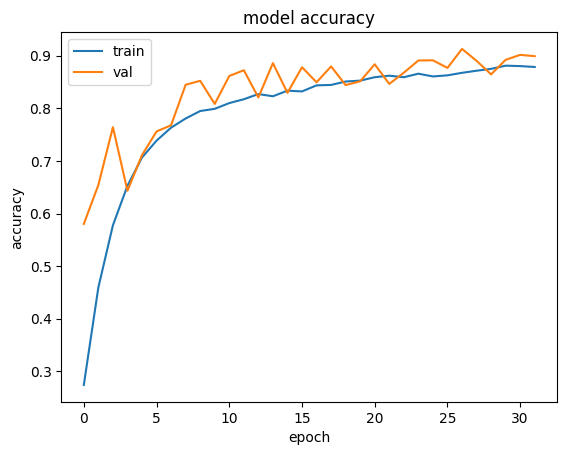

In [102]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

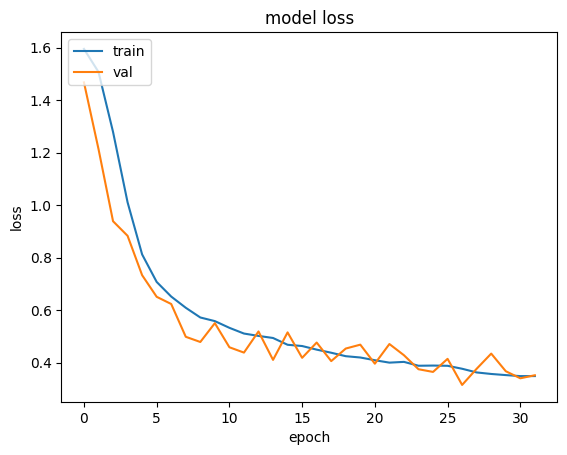

In [103]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [104]:
test_loss, test_accuracy = model.evaluate(test_X_list, test_Y_list)

97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.7058 - loss: 0.7324


In [105]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X_list[0].shape)
print("Test Y shape:", test_Y_list[0].shape)

Test X shape: (3073, 80, 6)
Test Y shape: (3073, 5)


In [106]:
#predictions
predictions = model.predict(test_X_list)

97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step


In [107]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y_list, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 67.30%
Predicted classes: [1 0 4 ... 0 0 4]
True classes: [[4 0 4 ... 0 0 4]
 [4 0 4 ... 0 0 4]
 [4 0 4 ... 0 0 4]
 ...
 [4 0 4 ... 0 0 4]
 [4 0 4 ... 0 0 4]
 [4 0 4 ... 0 0 4]]


In [108]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = np.array(predicted_classes)
true_classes_np = np.array(true_classes[0])

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print(f"Specificities (per class): {specificities}")

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")
f1 = f1_score(true_classes_np, predicted_classes_np, average='weighted')
# overall F1 score average
overall_F1 = round(math.fsum(f1_scores) / len(f1_scores),2)
print(f"Overall F1 Score: {overall_F1}")


Classification Report:
               precision    recall  f1-score   support

           0     0.6158    0.7291    0.6677       587
           1     0.5390    0.7739    0.6354       429
           2     0.2450    0.7625    0.3708        80
           3     0.9653    0.8146    0.8836       205
           4     0.8060    0.6095    0.6941      1772

    accuracy                         0.6730      3073
   macro avg     0.6342    0.7379    0.6503      3073
weighted avg     0.7284    0.6730    0.6851      3073

Confusion Matrix:
 [[ 428    5   11    0  143]
 [   2  332    1    2   92]
 [   8    1   61    0   10]
 [   0   22    1  167   15]
 [ 257  256  175    4 1080]]
F1-Scores (per class): [0.72913118 0.77389277 0.7625     0.81463415 0.60948081]
Specificities (per class): [0.8925985518905873, 0.8925869894099848, 0.9371867691279653, 0.997907949790795, 0.8001537279016141]
F1-Scores (per class): [0.72913118 0.77389277 0.7625     0.81463415 0.60948081]
Overall F1 Score: 0.74


In [109]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in [0,1,2,3,4]:
     prec,recall,_,_ = precision_recall_fscore_support(np.array(true_classes_np)==l,
                                                  np.array(predicted_classes_np)==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

sens_spes = pd.DataFrame(res,columns = ['class','specificity','sensitivity'])
print(sens_spes)

overall_specificity = sens_spes['specificity'].mean()
overall_sensitivity = sens_spes['sensitivity'].mean()
print(f"Overall specificity: {round(overall_specificity,2)}")
print(f"Overall sensitivity: {round(overall_sensitivity, 2)}")

   class  specificity  sensitivity
0      0     0.892599     0.729131
1      1     0.892587     0.773893
2      2     0.937187     0.762500
3      3     0.997908     0.814634
4      4     0.800154     0.609481
Overall specificity: 0.9
Overall sensitivity: 0.74


## Confusion Matrix

In [110]:
true_classes = true_classes[0].numpy()
predicted_classes = predicted_classes.numpy()

In [111]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

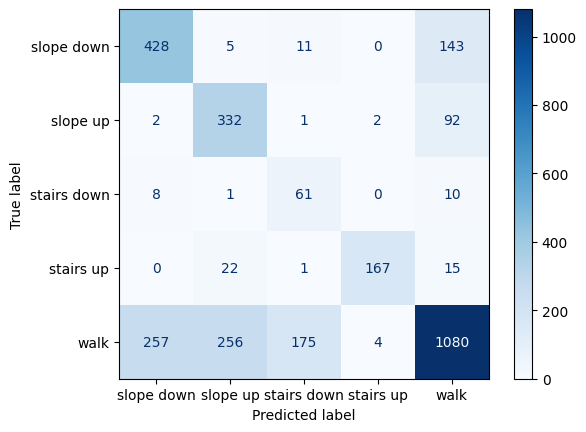

In [112]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

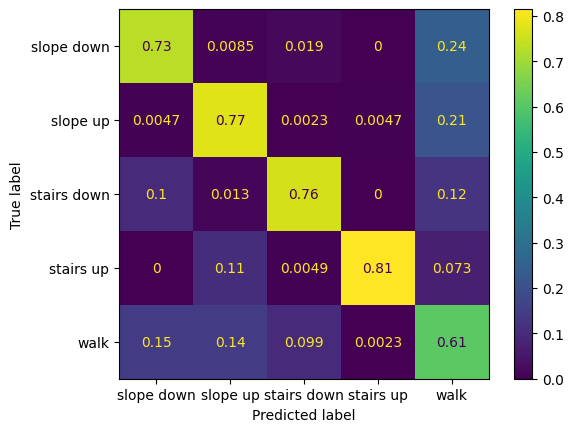

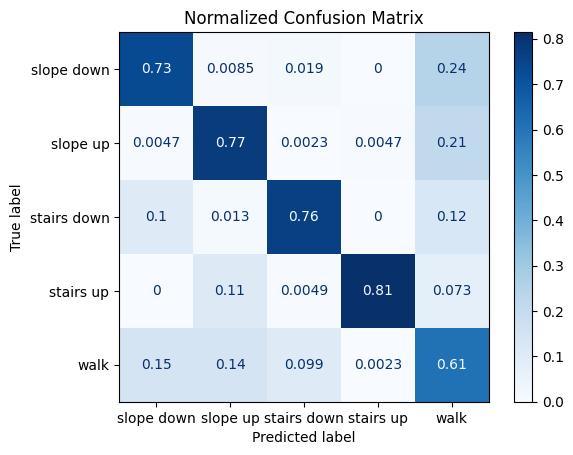

In [113]:
# Create the confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [114]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [115]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE